In [2]:
import preprocess_general
import preprocess_meteo
from pathlib import Path
import yaml
from preprocess_meteo import ERA5LandAnalyzer
from preprocess_catchment import CatchmentProcessor
from preprocess_catchment import HRUConnectivityCalculator
from preprocess_streamflow import StreamflowProcessor
from preprocess_meteo import GridWeightsGenerator


In [3]:
namelist_path = "../namelist_0115.yaml"  # Adjust path if needed

with open(namelist_path, "r") as f:
    nml = yaml.safe_load(f)


In [5]:
preprocess_general.create_folder(namelist_path)

In [4]:
# Debug your precipitation data
analyzer = ERA5LandAnalyzer(namelist_path)

# Find the precipitation file
file_info = analyzer.get_processed_files_info()
if 'precipitation' in file_info:
    precip_file = file_info['precipitation']
    analyzer.debug_precipitation_values(precip_file)
else:
    print("No precipitation file found")

2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO - Warm-up period configured: 1978-01-01 to 1979-12-31
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - DEBUG - Loading catchment shapefile for gauge ID: 0115
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - DEBUG - Looking for catchment shapefile at: /home/jberg/OneDrive/Raven_worldwide/01_data/topo/catchment_shapefile/catchment_shape_0115.shp


2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO - ✅ Loaded catchment shapefile with 1 features
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO -    Original CRS: EPSG:4326
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO -    Catchment bounds: lon [75.9440, 79.6129], lat [33.6854, 35.6796]
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO - Processing for gauge 0115 using basin 0115 meteo data
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO - Model type: HBV
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO - Coupled mode: True
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO - Model directory: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO - ERA5 data directory: /home/jberg/OneDrive/Raven_worldwide/01_data/meteo/gauge_0115
2026-01-22 15:24:46 - ERA5LandAnalyzer_Gauge_0115 - INFO - Plots will be saved to: /home/jberg/OneDrive/Raven_worldwide/03_model_

No precipitation file found


Warm-up period configured: 1978-01-01 to 1980-01-01
📂 Loaded streamflow data with shape: (9834, 2)
📅 Date range: 1973-01-01 to 1999-12-04
📅 After time subsetting: 7670 records

🔍 Checking for missing data and dates...
   📊 Found 365 NaN values in original data
   🔄 Including warm-up period from 1978-01-01
   📅 Expected date range: 1978-01-01 to 1998-12-31
   📅 Expected total days: 7670
   📅 Original data days: 7670
   🔄 Warm-up period: 730 days filled with -1.2345
      (1978-01-01 to 1979-12-31)
   🔍 Missing dates in simulation period: 365
   📋 First few missing dates: ['1998-01-01', '1998-01-02', '1998-01-03', '1998-01-04', '1998-01-05']
   📋 Last few missing dates: ['1998-12-27', '1998-12-28', '1998-12-29', '1998-12-30', '1998-12-31']
   ✅ Total values filled with -1.2345: 1095
      • Warm-up period: 730
      • Original NaN values: 365
      • Missing dates: 365

📊 Final dataset summary:
   • Total records: 7670
   • Valid observations: 6575
   • Missing/filled values: 1095
   • D

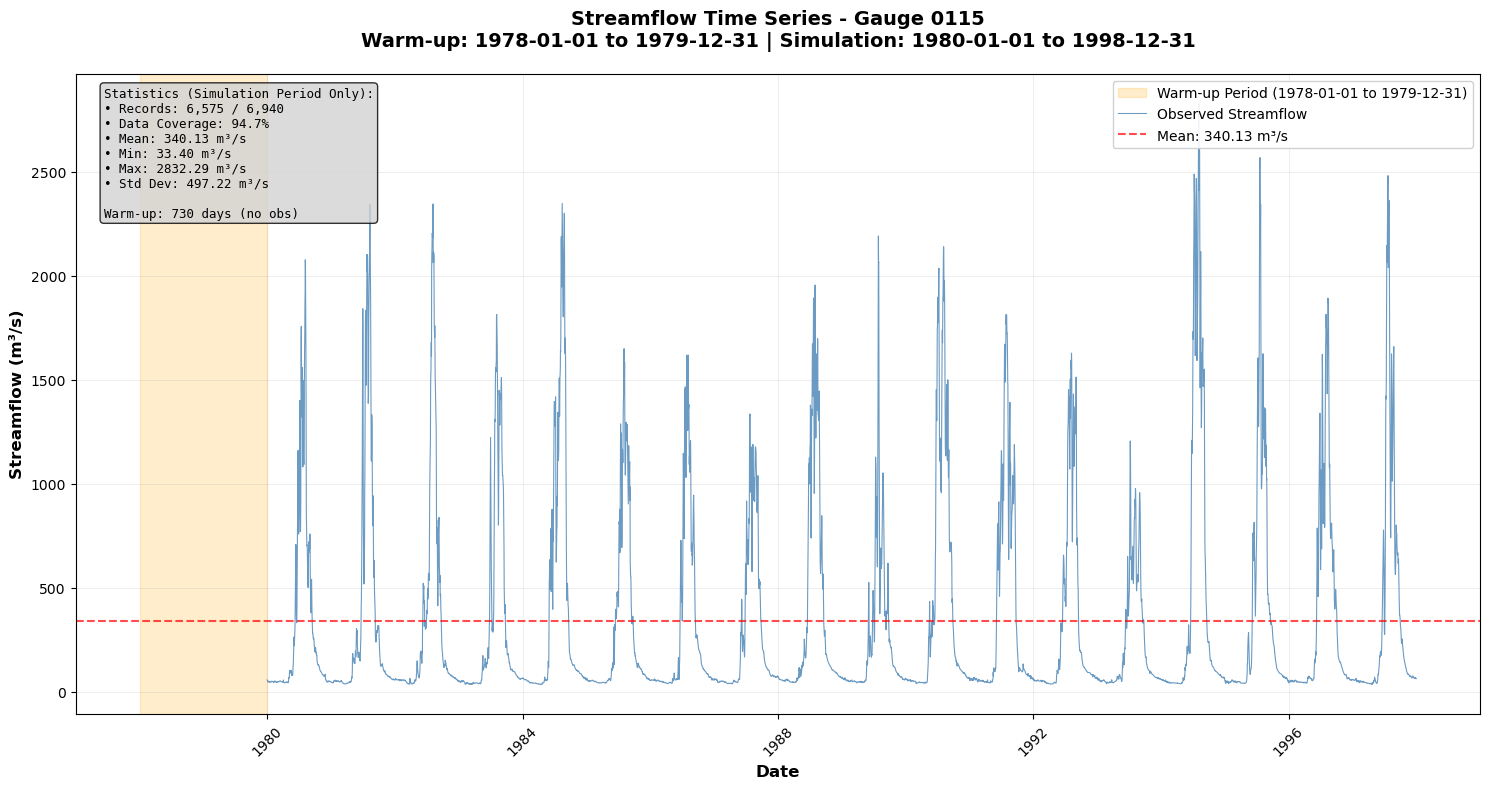

   📅 RVT file will start at warm-up date: 1978-01-01
✅ Successfully processed streamflow data for gauge 0115
📁 RVT file: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0115/HBV/data_obs/Q_daily.rvt
📊 Plot saved: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0115/HBV/plots/streamflow_timeseries_gauge_0115.png


In [4]:
processor = StreamflowProcessor(namelist_path)
success = processor.process()

In [6]:
# Create the processor instance
print("Initializing CatchmentProcessor...")
processor = CatchmentProcessor(namelist_path)

print(f"✅ Processor initialized!")
print(f"📊 Configuration:")
print(f"   - Gauge ID: {processor.gauge_id}")
print(f"   - Model directory: {processor.model_dir}")
print(f"   - Criteria: {processor.criteria}")
print(f"   - Elevation distance: {processor.elevation_distance} m")
print(f"   - Debug mode: {processor.debug}")

2026-01-22 15:24:54 - CatchmentProcessor_Gauge_0115 - DEBUG - Created directory structure at /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0115/topo_files


Initializing CatchmentProcessor...
✅ Processor initialized!
📊 Configuration:
   - Gauge ID: 0115
   - Model directory: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0115
   - Criteria: ['elevation', 'landuse']
   - Elevation distance: 100 m
   - Debug mode: True


In [7]:
print("🚀 Starting complete catchment processing...")
print("="*60)

try:
    # This runs everything: DEM clipping, slope/aspect calculation, 
    # landuse reclassification, glacier processing, HRU discretization, 
    # statistics calculation, shapefile creation, and HRU table generation
    hru_table = processor.process_catchment()
    
    print(f"\n🎉 Processing completed successfully!")
    print(f"📋 Created HRU table with {len(hru_table)} HRUs")
    print(f"📁 Files saved in: {processor.get_path('')}")
    
except Exception as e:
    print(f"❌ Error during processing: {e}")
    import traceback
    traceback.print_exc()

2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - INFO - Processing catchment 0115
2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - INFO - Extracting catchment shape for gauge ID 0115
2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - INFO - Clipping DEM for catchment 0115
2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - DEBUG - Using existing clipped DEM at /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0115/topo_files/clipped_dem.tif
2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - INFO - Calculating slope and aspect from SRTM DEM
2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - DEBUG - Using existing slope and aspect files
2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - INFO - Reclassifying ESA WorldCover landuse
2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - DEBUG - Using existing reclassified landuse at /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0115/topo_files/reclassifie

🚀 Starting complete catchment processing...


2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - INFO - Rasterizing RGI6 glacier shapefile
2026-01-22 15:24:57 - CatchmentProcessor_Gauge_0115 - DEBUG - Using existing glacier raster at /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0115/topo_files/glacier_raster.tif
2026-01-22 15:24:58 - CatchmentProcessor_Gauge_0115 - INFO - Discretizing catchment using criteria: ['elevation', 'landuse']


🔍 Debugging catchment processing...
📁 Topo directory: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0115/topo_files
   - Exists: True
   - Files: ['reclassified_landuse.tif', 'glacier_id_mapping.csv', 'clipped_glacier.shx', 'clipped_glacier.shp', 'clipped_glacier.dbf', 'glacier_raster.tif', 'slope.tif', 'clipped_glacier.cpg', 'clipped_glacier.prj', 'aspect.tif', 'clipped_dem.tif']
   - Glacier raster unique values: [1.000e+00 2.000e+00 3.000e+00 ... 4.014e+03 4.015e+03 4.016e+03]
   - Glacier raster shape: (8086, 12618)
📊 Data array shapes:
   - DEM: (8086, 12618)
   - Slope: (8086, 12618)
   - Aspect: (8086, 12618)
   - Landuse: (8086, 12618)
   - Glacier: (8086, 12618)
🧊 Glacier ID mapping: {}
🎯 Criteria dictionary: {'elevation': [array([2400., 2500.]), array([2500., 2600.]), array([2600., 2700.]), array([2700., 2800.]), array([2800., 2900.]), array([2900., 3000.]), array([3000., 3100.]), array([3100., 3200.]), array([3200., 3300.]), array([3300., 34

2026-01-22 15:25:13 - CatchmentProcessor_Gauge_0115 - INFO - Creating 3992 glacier HRUs
2026-01-22 15:25:13 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 1 for RGI60-11.00001
2026-01-22 15:25:14 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 2 for RGI60-11.00002
2026-01-22 15:25:14 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 3 for RGI60-11.00003
2026-01-22 15:25:15 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 4 for RGI60-11.00004
2026-01-22 15:25:15 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 5 for RGI60-11.00005
2026-01-22 15:25:15 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 6 for RGI60-11.00006
2026-01-22 15:25:16 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 7 for RGI60-11.00007
2026-01-22 15:25:16 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 8 for RGI60-11.00008
2026-01-22 15:25:17 - CatchmentProcessor_Gauge_0115 - DEBUG - Created glacier HRU 9 for 

: 

In [7]:
# This will automatically construct model_dir the same way as CatchmentProcessor
connectivity_calc = HRUConnectivityCalculator(namelist_path)
connectivity_df = connectivity_calc.calculate_connectivity()

2026-01-19 10:21:05 - HRUConnectivityCalculator_Gauge_0102 - INFO - HRU Connectivity Calculator for gauge 0102
2026-01-19 10:21:05 - HRUConnectivityCalculator_Gauge_0102 - INFO - 📁 Shared connectivity files: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0102/data_obs
2026-01-19 10:21:05 - HRUConnectivityCalculator_Gauge_0102 - INFO - 📋 Files will be copied to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0102/HBV/data_obs
2026-01-19 10:21:05 - HRUConnectivityCalculator_Gauge_0102 - INFO - Calculating HRU connectivity for gauge 0102
2026-01-19 10:21:05 - HRUConnectivityCalculator_Gauge_0102 - INFO - ✅ Connectivity files already exist
2026-01-19 10:21:05 - HRUConnectivityCalculator_Gauge_0102 - INFO - ⏭️  Skipping connectivity calculation
2026-01-19 10:21:05 - HRUConnectivityCalculator_Gauge_0102 - INFO - 💡 Delete files to force reprocessing:
2026-01-19 10:21:05 - HRUConnectivityCalculator_Gauge_0102 - INFO -    rm /hom

2026-01-05 11:31:11 - GridWeightsGenerator_Gauge_0647 - DEBUG - Initialized GridWeightsGenerator with:
2026-01-05 11:31:11 - GridWeightsGenerator_Gauge_0647 - DEBUG -   Model dir: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647
2026-01-05 11:31:11 - GridWeightsGenerator_Gauge_0647 - DEBUG -   Gauge ID: 0647
2026-01-05 11:31:11 - GridWeightsGenerator_Gauge_0647 - DEBUG -   Model type: HBV
2026-01-05 11:31:11 - GridWeightsGenerator_Gauge_0647 - DEBUG -   Output dir: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/data_obs
2026-01-05 11:31:11 - GridWeightsGenerator_Gauge_0647 - DEBUG -   HRU shapefile: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/topo_files/HRU.shp
2026-01-05 11:31:11 - GridWeightsGenerator_Gauge_0647 - INFO - Generating ERA5-Land grid weights for catchment 0647
2026-01-05 11:31:11 - GridWeightsGenerator_Gauge_0647 - DEBUG - Loading ERA5-Land precipitation data from /home/jberg/OneD

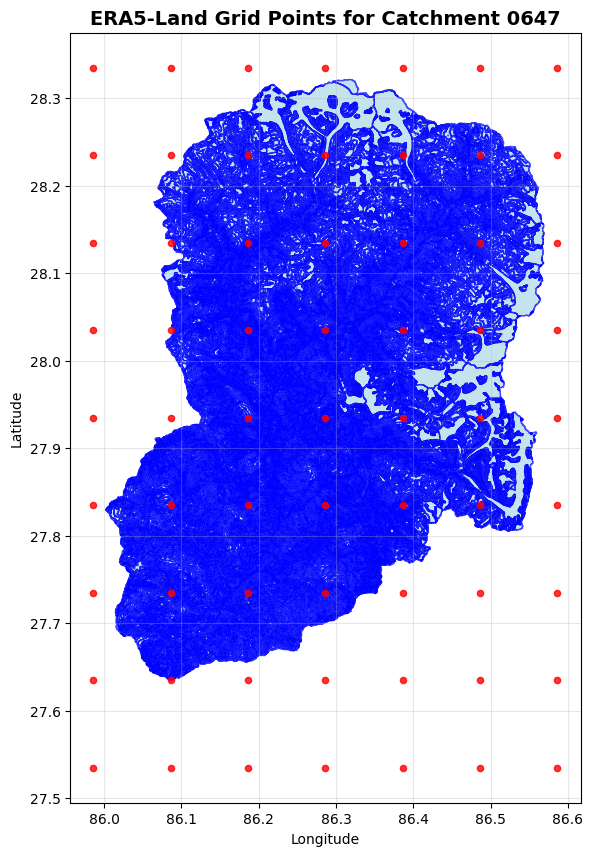

2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Creating polygon grid from ERA5-Land point data
2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Grid bounds (WGS84): xmin=85.986200, xmax=86.586371, ymin=27.535000, ymax=28.335000
2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Inferring cell size from ERA5-Land grid spacing
2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Number of unique X coordinates: 7
2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Number of unique Y coordinates: 9
2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Inferred ERA5-Land cell size: width=0.100029°, height=0.100000°
2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Creating grid with 7 columns and 9 rows
2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Expected total cells: 63
2026-01-05 11:31:33 - GridWeightsGenerator_Gauge_0647 - DEBUG - Actual data points: 63
2026-01-05 11:31:33 - Gr

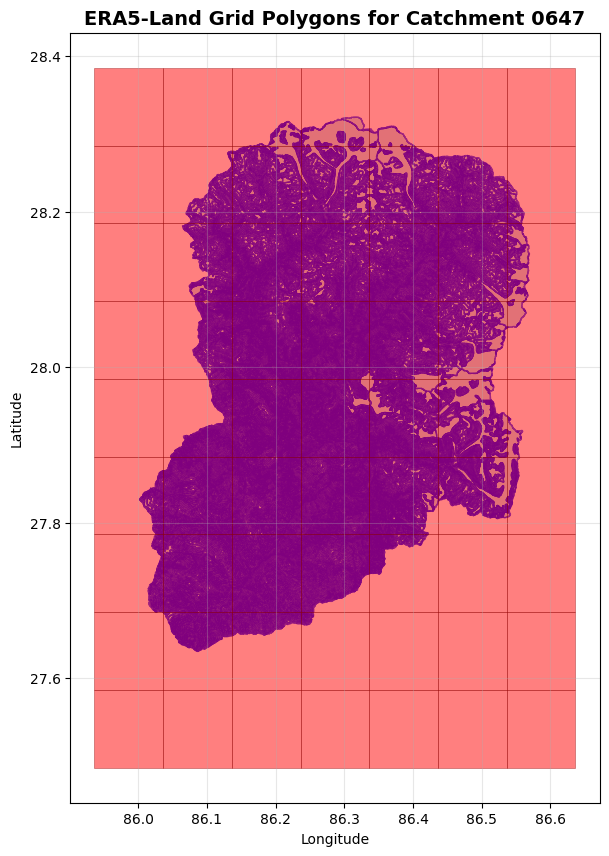

2026-01-05 11:31:54 - GridWeightsGenerator_Gauge_0647 - DEBUG - Creating overlay of ERA5-Land grid and HRU shapes
2026-01-05 11:31:54 - GridWeightsGenerator_Gauge_0647 - DEBUG - Reprojecting HRU from EPSG:32645 to EPSG:4326
2026-01-05 11:31:55 - GridWeightsGenerator_Gauge_0647 - DEBUG - Grid CRS: EPSG:4326, HRU CRS: EPSG:4326
2026-01-05 11:32:02 - GridWeightsGenerator_Gauge_0647 - DEBUG - Created overlay with 2941 intersections
2026-01-05 11:32:02 - GridWeightsGenerator_Gauge_0647 - DEBUG - Calculating relative areas for ERA5-Land grid cells
2026-01-05 11:32:02 - GridWeightsGenerator_Gauge_0647 - DEBUG - Using HRU ID column: HRU_ID
2026-01-05 11:32:02 - GridWeightsGenerator_Gauge_0647 - DEBUG - Processing 592 HRUs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.

In [10]:
# Generate grid weights
generator = GridWeightsGenerator(namelist_path)
grid_weights = generator.generate()

In [31]:
from preprocess_glogem_new import GloGEMProcessor
glogem_processor = GloGEMProcessor(namelist_path)  # ✅ Same pattern!

2026-01-21 13:27:27 - GloGEMProcessor - INFO - GloGEM Processor initialized for gauge 0118
2026-01-21 13:27:27 - GloGEMProcessor - INFO - 📁 Shared irrigation files: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance/catchment_0118/data_obs
2026-01-21 13:27:27 - GloGEMProcessor - INFO - 📋 Files will be copied to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance/catchment_0118/HBV/data_obs
2026-01-21 13:27:27 - GloGEMProcessor - INFO - 🔄 Warm-up period: 1984-01-01 to 1986-01-01


Warm-up period configured: 1984-01-01 to 1986-01-01


2026-01-21 13:27:28 - GloGEMProcessor - INFO - ============================================================
2026-01-21 13:27:28 - GloGEMProcessor - INFO - Starting GloGEM processing for gauge 0118
2026-01-21 13:27:28 - GloGEMProcessor - INFO - ============================================================
2026-01-21 13:27:28 - GloGEMProcessor - INFO - 
1. Processing GloGEM .dat files...
2026-01-21 13:27:28 - GloGEMProcessor - INFO - Processing GloGEM files...
2026-01-21 13:27:29 - GloGEMProcessor - INFO - Auto-detected RGI region code: RGI60-14
2026-01-21 13:27:29 - GloGEMProcessor - INFO - Looking for 814 glacier IDs
2026-01-21 13:27:29 - GloGEMProcessor - INFO - Processing icemelt files...
2026-01-21 13:27:29 - GloGEMProcessor - INFO - Found 2 icemelt files
2026-01-21 13:27:29 - GloGEMProcessor - INFO - Reading GloGEM_icemelt_0118_large.dat (memory-efficient mode)...
2026-01-21 13:27:33 - GloGEMProcessor - INFO - Reading GloGEM_icemelt_0118_small.dat (memory-efficient mode)...
2026-01-

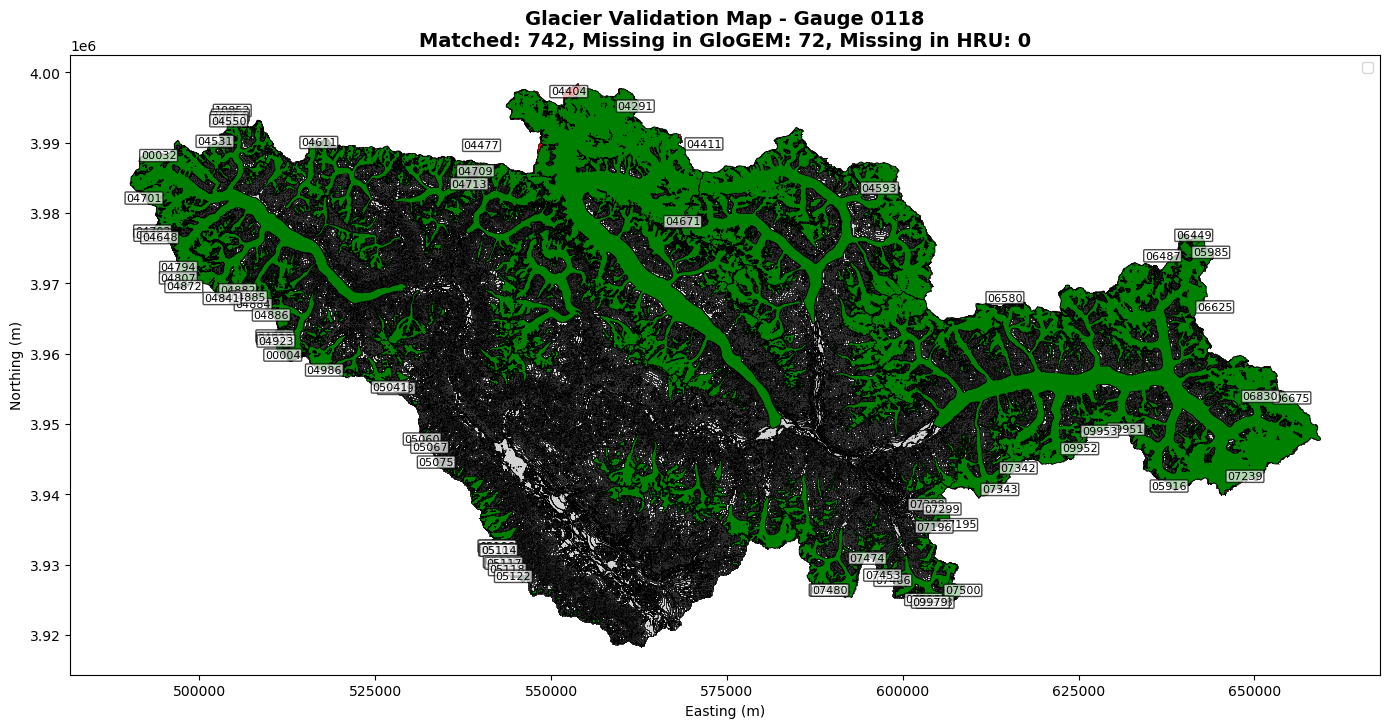

2026-01-21 13:32:40 - GloGEMProcessor - INFO - 
6. Creating glacier runoff vs observed streamflow plots...
2026-01-21 13:32:40 - GloGEMProcessor - INFO - Creating glacier runoff vs observed streamflow comparison plots...
2026-01-21 13:32:43 - GloGEMProcessor - INFO - Catchment area: 6711.46 km²
2026-01-21 13:32:43 - GloGEMProcessor - INFO - Glacier area: 2979.56 km² (44.4%)


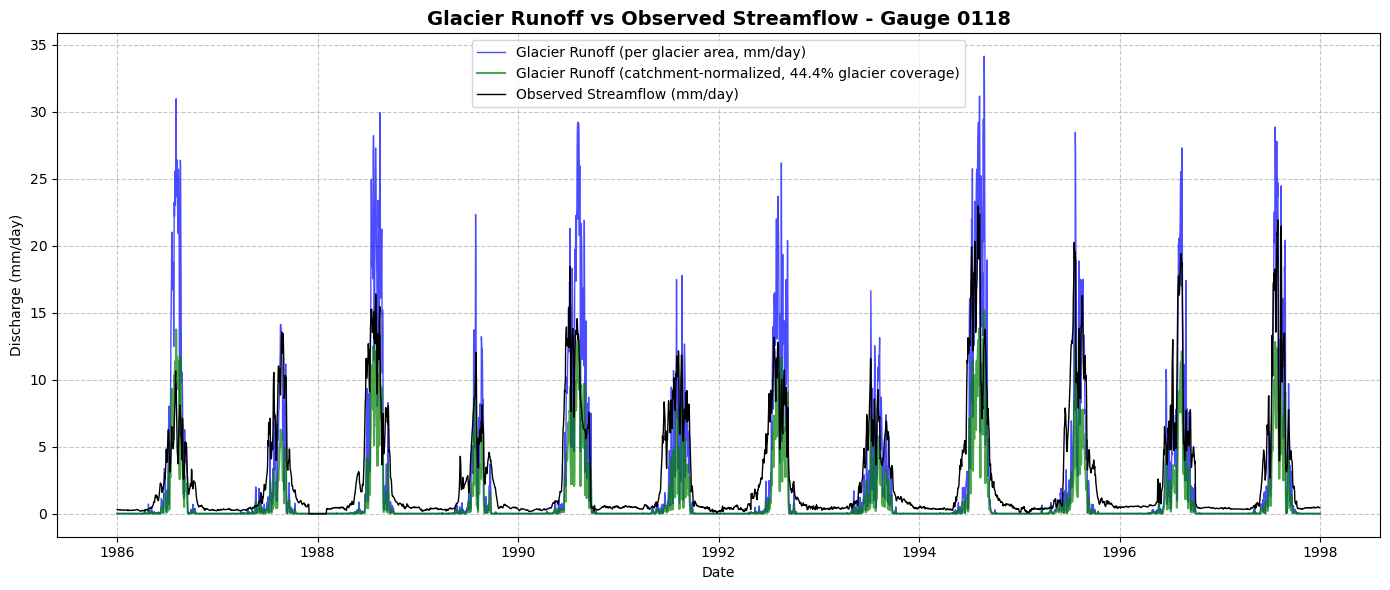

2026-01-21 13:32:46 - GloGEMProcessor - INFO - ✅ Time series plot saved: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance/catchment_0118/plots/glacier_runoff_vs_observed_mm.png


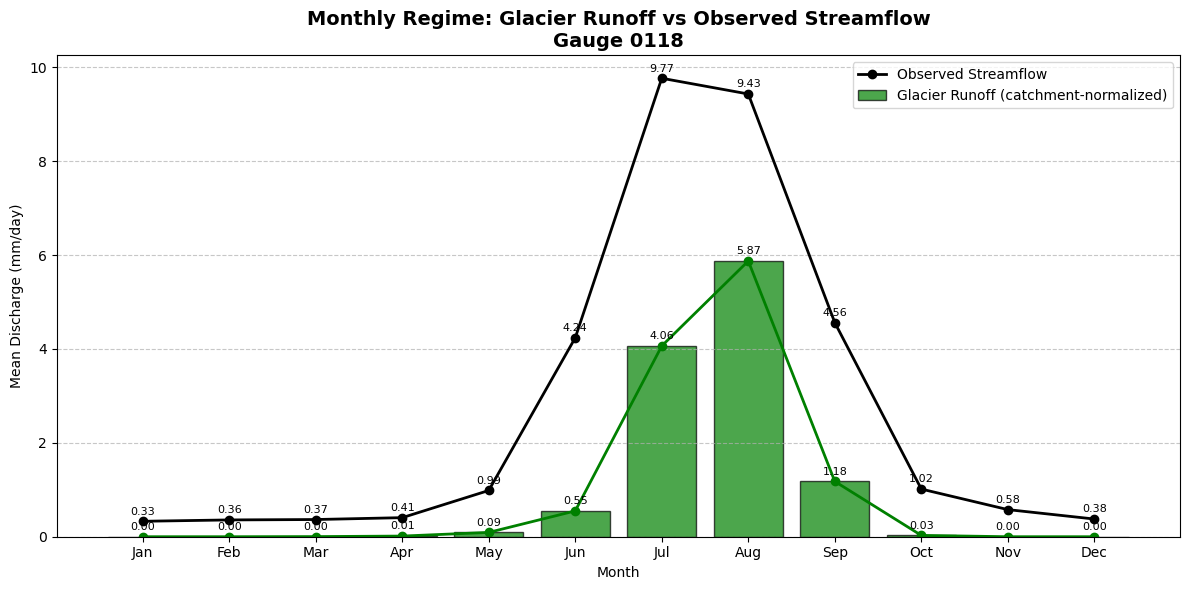

2026-01-21 13:32:48 - GloGEMProcessor - INFO - ✅ Monthly regime plot saved: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance/catchment_0118/plots/monthly_regime_glacier_vs_observed.png
2026-01-21 13:32:48 - GloGEMProcessor - INFO - 
2026-01-21 13:32:48 - GloGEMProcessor - INFO - GLACIER RUNOFF VS OBSERVED STREAMFLOW STATISTICS
2026-01-21 13:32:48 - GloGEMProcessor - INFO - ============================================================
2026-01-21 13:32:48 - GloGEMProcessor - INFO - Catchment area: 6711.46 km²
2026-01-21 13:32:48 - GloGEMProcessor - INFO - Glacier area: 2979.56 km² (44.4%)
2026-01-21 13:32:48 - GloGEMProcessor - INFO - Mean glacier runoff (per glacier area): 2.25 mm/day
2026-01-21 13:32:48 - GloGEMProcessor - INFO - Mean glacier runoff (catchment-normalized): 1.00 mm/day
2026-01-21 13:32:48 - GloGEMProcessor - INFO - Mean observed streamflow: 2.72 mm/day
2026-01-21 13:32:48 - GloGEMProcessor - INFO - Glacier contribution to streamflow: 36.


🎉 GloGEM processing completed successfully!
📊 Results summary:
   - GloGEM records: 3249960
   - Glaciers matched: 742
   - Missing in GloGEM: 72
   - Comparison plots created in: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance/catchment_0118/plots/


In [32]:
results = glogem_processor.process_all()
    
print(f"\n🎉 GloGEM processing completed successfully!")
print(f"📊 Results summary:")
print(f"   - GloGEM records: {len(results['glogem_data'])}")
print(f"   - Glaciers matched: {len(results['validation']['matched'])}")
print(f"   - Missing in GloGEM: {len(results['validation']['missing_in_glogem'])}")
print(f"   - Comparison plots created in: {glogem_processor.model_dir}/catchment_{glogem_processor.gauge_id}/plots/")

In [5]:
from preprocess_HBV import HBVProcessor

# Initialize processor
processor = HBVProcessor(namelist_path)

# Generate all HBV files
processor.create_all_files(template=False)  # Regular files
processor.create_all_files(template=True)   # Template files for optimization

Warm-up period configured: 1978-01-01 to 1980-01-01
✅ Loaded parameters from: ../src/config/default_params.yaml
Creating initialized HBV files for catchment 0102
DEBUG: template=False, param_or_name=init
DEBUG: Available keys in self.params['HBV']['init']: ['X01', 'X02', 'X03', 'X04', 'X05']...
Successfully read HRU table from /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0102/topo_files/HRU_table.csv
Total HRUs: 2534
Excluded HRUs from AllHRUs group (land use ['GLACIER', 'ROCK', 'MASKED_GLACIER', 'LAKE']): 2418
AllHRUs group will contain: 116 HRUs
ALL_GLACIER group: 2309 HRUs
SMALL_GLACIER group: 2061 HRUs (area < 2 km²)
LARGE_GLACIER group: 248 HRUs (area >= 2 km²)
NO_GLACIER group: 225 HRUs
Found 63 elevation bands with a total of 225 HRUs
  1400-1500m: 6 HRUs
  1500-1600m: 6 HRUs
  1600-1700m: 6 HRUs
  1700-1800m: 6 HRUs
  1800-1900m: 6 HRUs
  1900-2000m: 6 HRUs
  2000-2100m: 6 HRUs
  2100-2200m: 6 HRUs
  2200-2300m: 6 HRUs
  2300-2400m: 6 HRUs
  2

In [5]:
from preprocess_HYMOD import HYMODPreprocessor
import yaml

# Initialize processor
processor = HYMODPreprocessor(namelist_path)

# Generate all HYMOD files
processor.create_all_files(template=False)  # Regular files
processor.create_all_files(template=True)   # Template files for optimization

✅ Loaded parameters from: ../src/config/default_params.yaml
Creating initialized HYMOD files for catchment 0102
Successfully read HRU table from /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/topo_files/HRU_table.csv
Total HRUs: 2534
Excluded HRUs from AllHRUs group (land use ['GLACIER', 'ROCK', 'MASKED_GLACIER', 'LAKE']): 2418
AllHRUs group will contain: 116 HRUs
ALL_GLACIER group: 2309 HRUs
SMALL_GLACIER group: 2061 HRUs (area < 2 km²)
LARGE_GLACIER group: 248 HRUs (area >= 2 km²)
NO_GLACIER group: 225 HRUs
Excluded 2309 HRUs from elevation bands (land use: ['GLACIER', 'MASKED_GLACIER'])
Found 63 elevation bands with a total of 225 HRUs (glaciers excluded)
  1400-1500m: 6 HRUs
  1500-1600m: 6 HRUs
  1600-1700m: 6 HRUs
  1700-1800m: 6 HRUs
  1800-1900m: 6 HRUs
  1900-2000m: 6 HRUs
  2000-2100m: 6 HRUs
  2100-2200m: 6 HRUs
  2200-2300m: 6 HRUs
  2300-2400m: 6 HRUs
  2400-2500m: 6 HRUs
  2500-2600m: 6 HRUs
  2600-2700m: 6 HRUs
  2700-2800m: 6 HRUs
  2800-290

In [5]:
from preprocess_MOHYSE import MOHYSEPreprocessor
import yaml

# Initialize processor
processor = MOHYSEPreprocessor(namelist_path)

# Generate all MOHYSE files
processor.create_all_files(template=False)
processor.create_all_files(template=True)

✅ Loaded parameters from: ../src/config/default_params.yaml
Creating initialized MOHYSE files for catchment 0102
Successfully read HRU table from /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/topo_files/HRU_table.csv
Total HRUs: 2534
Excluded HRUs from AllHRUs group (land use ['GLACIER', 'ROCK', 'MASKED_GLACIER', 'LAKE']): 2418
AllHRUs group will contain: 116 HRUs
ALL_GLACIER group: 2309 HRUs
SMALL_GLACIER group: 2061 HRUs (area < 2 km²)
LARGE_GLACIER group: 248 HRUs (area >= 2 km²)
NO_GLACIER group: 225 HRUs
Excluded 2309 HRUs from elevation bands (land use: ['GLACIER', 'MASKED_GLACIER'])
Found 63 elevation bands with a total of 225 HRUs (glaciers excluded)
  1400-1500m: 6 HRUs
  1500-1600m: 6 HRUs
  1600-1700m: 6 HRUs
  1700-1800m: 6 HRUs
  1800-1900m: 6 HRUs
  1900-2000m: 6 HRUs
  2000-2100m: 6 HRUs
  2100-2200m: 6 HRUs
  2200-2300m: 6 HRUs
  2300-2400m: 6 HRUs
  2400-2500m: 6 HRUs
  2500-2600m: 6 HRUs
  2600-2700m: 6 HRUs
  2700-2800m: 6 HRUs
  2800-29

In [4]:
from preprocess_HMETS import HMETSPreprocessor

# Initialize processor
processor = HMETSPreprocessor(namelist_path)

# Generate all HMETS files
processor.create_all_files(template=False)  # Regular files
processor.create_all_files(template=True)   # Template files for optimization

✅ Loaded parameters from: ../src/config/default_params.yaml
Creating initialized HMETS files for catchment 0102
Successfully read HRU table from /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/topo_files/HRU_table.csv
Total HRUs: 2534
Excluded HRUs from AllHRUs group (land use ['GLACIER', 'ROCK', 'MASKED_GLACIER', 'LAKE']): 2418
AllHRUs group will contain: 116 HRUs
ALL_GLACIER group: 2309 HRUs
SMALL_GLACIER group: 2061 HRUs (area < 2 km²)
LARGE_GLACIER group: 248 HRUs (area >= 2 km²)
NO_GLACIER group: 225 HRUs
Excluded 2309 HRUs from elevation bands (land use: ['GLACIER', 'MASKED_GLACIER'])
Found 63 elevation bands with a total of 225 HRUs (glaciers excluded)
  1400-1500m: 6 HRUs
  1500-1600m: 6 HRUs
  1600-1700m: 6 HRUs
  1700-1800m: 6 HRUs
  1800-1900m: 6 HRUs
  1900-2000m: 6 HRUs
  2000-2100m: 6 HRUs
  2100-2200m: 6 HRUs
  2200-2300m: 6 HRUs
  2300-2400m: 6 HRUs
  2400-2500m: 6 HRUs
  2500-2600m: 6 HRUs
  2600-2700m: 6 HRUs
  2700-2800m: 6 HRUs
  2800-290